# 📊 Agregatsiya va Guruhlash (SQLite)

## 🎯 Mavzu: SQL aggregation funksiyalari va GROUP BY - SQLite bilan ishlash

### 📋 Reja:
1. **Agregatsiya funksiyalari** - COUNT, SUM, AVG, MIN, MAX haqida batafsil
2. **GROUP BY operatori** - ma'lumotlarni guruhlash usullari
3. **HAVING filterlash** - guruhlangan ma'lumotlarni filtrlash
4. **Murakkab agregatsiya so'rovlari** - CTE, Sub-query va JOIN kombinatsiyalari
5. **SQLite xususiyatlari** - PostgreSQL dan farqlar va optimallashtirish

### 🎓 Ushbu darsda nima o'rganamiz:
- **SQLite** ma'lumotlar bazasida agregatsiya funksiyalaridan foydalanish
- **GROUP BY** bilan ma'lumotlarni samarali guruhlash
- **HAVING** operatori yordamida murakkab filtrlash
- **SQLite** ning afzalliklari va PostgreSQL dan farqlari
- Amaliy misollar va vizualizatsiya

---

## 🔌 SQLite ga ulanish

### 📖 SQLite haqida qisqacha:
**SQLite** - bu faylga asoslangan, server talab qilmaydigan ma'lumotlar bazasi tizimi. U:
- **O'rnatish talab qilmaydi** - Python bilan birga keladi
- **Fayl bazasi** - barcha ma'lumotlar bitta .db faylda saqlanadi
- **Tez va oson** - kichik va o'rta loyihalar uchun ideal
- **PostgreSQL ga qaraganda sodda** - lekin kuchli agregatsiya funksiyalariga ega

### 🔧 Kerakli kutubxonalarni import qilish:

In [6]:
import sqlite3
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

# SQLite ma'lumotlar bazasi fayli
database_path = 'datasets/lesson_aggregation.db'

# SQLAlchemy engine yaratish (SQLite uchun)
engine = create_engine(f'sqlite:///{database_path}')

# Bazadagi jadvallarni tekshirish
try:
    tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
    tables_df = pd.read_sql(tables_query, engine)
    print(f"\n📋 Mavjud jadvallar ({len(tables_df)} ta):")
    for table in tables_df['name']:
        print(f"   • {table}")
except Exception as e:
    print(f"⚠️  Jadvallarni tekshirishda xatolik: {e}")
    print("❓ Ma'lumotlar bazasi mavjudligini tekshiring!")


📋 Mavjud jadvallar (8 ta):
   • departments
   • sqlite_sequence
   • categories
   • customers
   • employees
   • products
   • orders
   • sales


## 1️⃣ Agregatsiya Funksiyalari

### 📝 Asosiy funksiyalar:

SQLite da quyidagi agregatsiya funksiyalari mavjud:

1. **COUNT()** - yozuvlar sonini hisoblash
   - `COUNT(*)` - barcha yozuvlar (NULL qiymatlar ham)
   - `COUNT(column)` - faqat NULL bo'lmagan qiymatlar
   - `COUNT(DISTINCT column)` - takrorlanmas qiymatlar

2. **SUM()** - yig'indini hisoblash
   - Faqat sonli ustunlar uchun
   - NULL qiymatlarni e'tiborga olmaydi

3. **AVG()** - o'rtacha qiymatni hisoblash
   - `SUM()/COUNT()` ga teng
   - NULL qiymatlarni hisobga olmaydi

4. **MIN()** - minimal qiymatni topish
5. **MAX()** - maksimal qiymatni topish

### 🔍 COUNT() funksiyasi - batafsil tahlil

🔍 COUNT() funksiyasining turlari:

👥 Jami xodimlar (COUNT(*)): 8
💰 Maoshi mavjud xodimlar: 8
🏢 Takrorlanmas bo'limlar: 8


📊 Bo'limlar bo'yicha batafsil statistika:
department_name  employee_count  high_salary_employees  avg_salary
        Finance               1                      1   6000000.0
             HR               1                      0   4500000.0
             IT               1                      1   8000000.0
      Marketing               1                      1   6500000.0
     Operations               1                      1   5500000.0
       Research               1                      1   9000000.0
          Sales               1                      1   7000000.0
        Support               1                      0   3500000.0


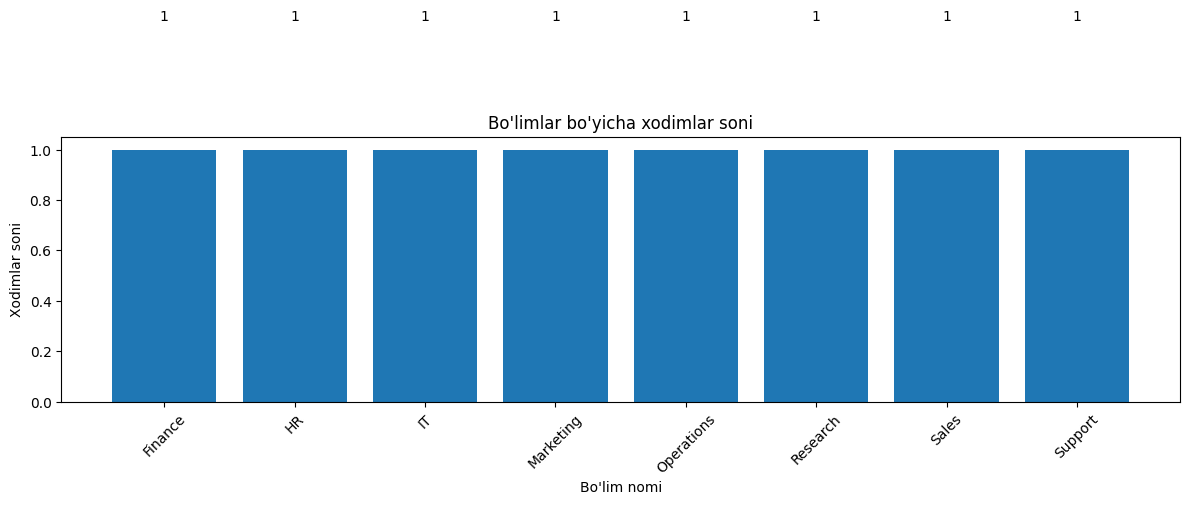

In [7]:
# COUNT() funksiyasining turli xillari
print("🔍 COUNT() funksiyasining turlari:\n")

# 1. Jami xodimlar soni (barcha yozuvlar)
query1 = """
SELECT COUNT(*) AS total_employees
FROM employees;
"""
df1 = pd.read_sql(query1, engine)
print(f"👥 Jami xodimlar (COUNT(*)): {df1['total_employees'][0]}")

# 2. Faqat ish haqi mavjud bo'lgan xodimlar
query2 = """
SELECT COUNT(salary) as employees_with_salary
FROM employees
WHERE salary IS NOT NULL;
"""
df2 = pd.read_sql(query2, engine)
print(f"💰 Maoshi mavjud xodimlar: {df2['employees_with_salary'][0]}")

# 3. Takrorlanmas bo'limlar soni
query3 = """
SELECT COUNT(DISTINCT department_id) as unique_departments
FROM employees;
"""
df3 = pd.read_sql(query3, engine)
print(f"🏢 Takrorlanmas bo'limlar: {df3['unique_departments'][0]}")

print("\n" + "="*50)

# Bo'limlar bo'yicha xodimlar soni (murakkab misol)
query = """
SELECT 
    d.department_name,
    COUNT(e.employee_id) AS employee_count,
    COUNT(CASE WHEN e.salary > 5000000 THEN 1 END) AS high_salary_employees,
    ROUND(AVG(e.salary), 0) AS avg_salary
FROM departments d 
LEFT JOIN employees e ON d.department_id = e.department_id
GROUP BY d.department_name
ORDER BY employee_count DESC;
"""

df = pd.read_sql(query, engine)
print("\n📊 Bo'limlar bo'yicha batafsil statistika:")
print(df.to_string(index=False))

# Vizualizatsiya
plt.figure(figsize=(12, 6))
bars = plt.bar(df['department_name'], df['employee_count'])
plt.xticks(rotation=45)
plt.title('Bo\'limlar bo\'yicha xodimlar soni')
plt.xlabel('Bo\'lim nomi')
plt.ylabel('Xodimlar soni')

# Raqamlarni ustiga yozish
for bar, count in zip(bars, df['employee_count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 💰 SUM() funksiyasi - batafsil

**SUM()** funksiyasi:
- Faqat **raqamli** ustunlar uchun ishlaydi
- **NULL** qiymatlarni e'tiborga olmaydi
- **DISTINCT** bilan birga ishlatilishi mumkin
- Katta raqamlarni qo'shishda aniqlikni saqlaydi

**SQLite da SUM() ning xususiyatlari:**
- INTEGER va REAL turlari bilan ishlaydi
- Agar barcha qiymatlar NULL bo'lsa, natija NULL bo'ladi
- Bo'sh to'plam uchun natija NULL (PostgreSQL dan farq!)

💰 SUM() funksiyasi tahlili:

📊 Asosiy maosh statistikasi:
Jami fond: 50,000,000 so'm
Jami xodimlar: 8
Hisoblangan o'rtacha: 6,250,000 so'm
AVG() funksiyasi: 6,250,000 so'm
Minimal: 3,500,000 so'm
Maksimal: 9,000,000 so'm


📊 Bo'limlar bo'yicha maosh fondi:
department_name  employee_count  employees_with_salary  total_salary  avg_salary  avg_salary_manual  min_salary  max_salary
       Research               1                      1     9000000.0   9000000.0          9000000.0   9000000.0   9000000.0
             IT               1                      1     8000000.0   8000000.0          8000000.0   8000000.0   8000000.0
          Sales               1                      1     7000000.0   7000000.0          7000000.0   7000000.0   7000000.0
      Marketing               1                      1     6500000.0   6500000.0          6500000.0   6500000.0   6500000.0
        Finance               1                      1     6000000.0   6000000.0          6000000.0   6000000.0   6000000.0

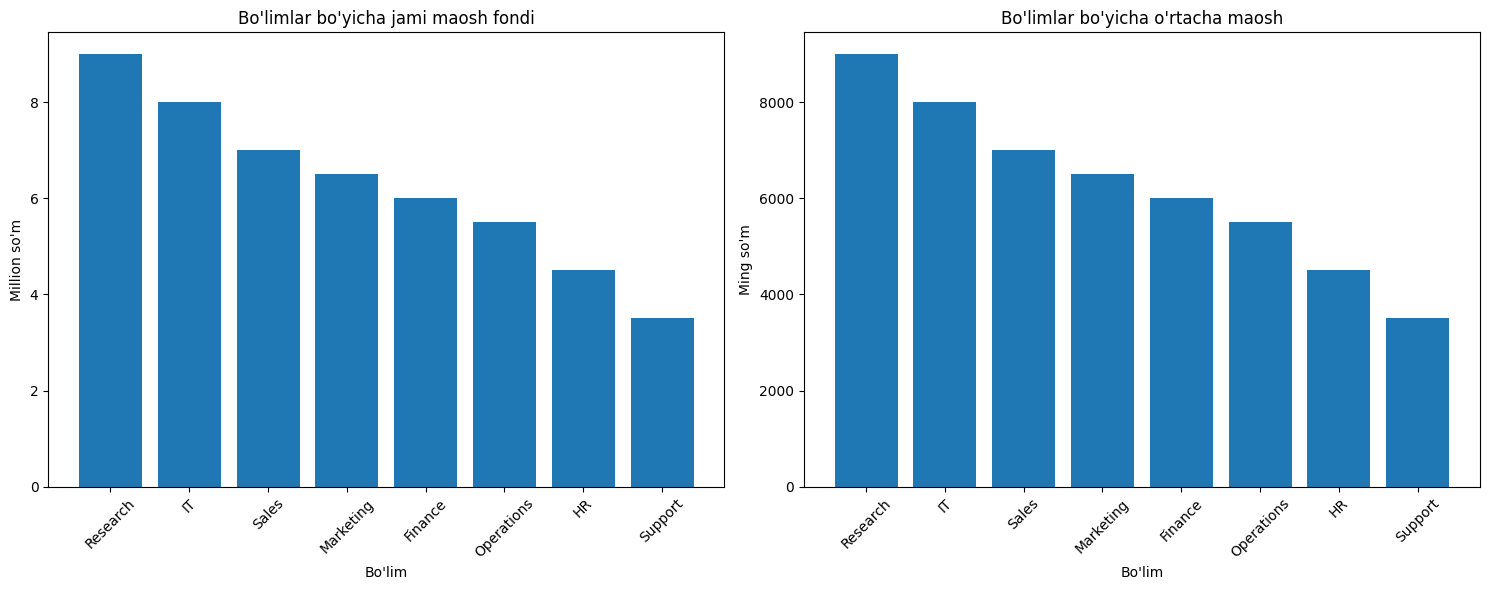

 NULL qiymatlar tahlili:
Jami yozuvlar: 8
Maoshi mavjud: 8
Maoshi yo'q: 0
Manual hisob: 0


In [8]:
# SUM() funksiyasining batafsil tahlili
print("💰 SUM() funksiyasi tahlili:\n")

# 1. Asosiy maosh statistikasi
query1 = """
SELECT 
    SUM(salary) as total_salary,
    COUNT(*) as total_employees,
    ROUND(SUM(salary)/COUNT(*), 0) as avg_salary_calculated,
    AVG(salary) as avg_salary_builtin,
    MIN(salary) as min_salary,
    MAX(salary) as max_salary
FROM employees
WHERE salary IS NOT NULL;
"""

df1 = pd.read_sql(query1, engine)
print("📊 Asosiy maosh statistikasi:")
print(f"Jami fond: {df1['total_salary'][0]:,.0f} so'm")
print(f"Jami xodimlar: {df1['total_employees'][0]}")
print(f"Hisoblangan o'rtacha: {df1['avg_salary_calculated'][0]:,.0f} so'm")
print(f"AVG() funksiyasi: {df1['avg_salary_builtin'][0]:,.0f} so'm")
print(f"Minimal: {df1['min_salary'][0]:,.0f} so'm")
print(f"Maksimal: {df1['max_salary'][0]:,.0f} so'm")

print("\n" + "="*50)

# 2. Bo'limlar bo'yicha batafsil maosh tahlili
query2 = """
SELECT 
    d.department_name,
    COUNT(e.employee_id) as employee_count,
    COUNT(e.salary) as employees_with_salary,
    SUM(e.salary) as total_salary,
    ROUND(AVG(e.salary), 0) as avg_salary,
    ROUND(SUM(e.salary)/COUNT(e.employee_id), 0) as avg_salary_manual,
    MIN(e.salary) as min_salary,
    MAX(e.salary) as max_salary
FROM departments d
LEFT JOIN employees e ON d.department_id = e.department_id
GROUP BY d.department_name
ORDER BY total_salary DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n📊 Bo'limlar bo'yicha maosh fondi:")
print(df2.to_string(index=False))

# Vizualizatsiya - ikkita grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1-grafik: Jami maosh fondi
bars1 = ax1.bar(df2['department_name'], df2['total_salary']/1e6)
ax1.set_title('Bo\'limlar bo\'yicha jami maosh fondi')
ax1.set_xlabel('Bo\'lim')
ax1.set_ylabel('Million so\'m')
ax1.tick_params(axis='x', rotation=45)

# 2-grafik: O'rtacha maosh
bars2 = ax2.bar(df2['department_name'], df2['avg_salary']/1e3)
ax2.set_title('Bo\'limlar bo\'yicha o\'rtacha maosh')
ax2.set_xlabel('Bo\'lim')
ax2.set_ylabel('Ming so\'m')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. NULL qiymatlar tahlili
query3 = """
SELECT 
    COUNT(*) as total_records,
    COUNT(salary) as non_null_salaries,
    COUNT(*) - COUNT(salary) as null_salaries,
    SUM(CASE WHEN salary IS NULL THEN 1 ELSE 0 END) as null_count_manual
FROM employees;
"""

df3 = pd.read_sql(query3, engine)
print(" NULL qiymatlar tahlili:")
      
print(f"Jami yozuvlar: {df3['total_records'][0]}")
print(f"Maoshi mavjud: {df3['non_null_salaries'][0]}")
print(f"Maoshi yo'q: {df3['null_salaries'][0]}")
print(f"Manual hisob: {df3['null_count_manual'][0]}")

### 📊 AVG() funksiyasi - batafsil tahlil

**AVG()** funksiyasi:
- **SUM()/COUNT()** ga teng
- Faqat **raqamli** qiymatlar bilan ishlaydi
- **NULL** qiymatlarni hisobga olmaydi
- **DISTINCT** bilan birga ishlatilishi mumkin

**SQLite da AVG() ning xususiyatlari:**
- INTEGER va REAL turlari bilan ishlaydi
- Agar barcha qiymatlar NULL bo'lsa, natija NULL bo'ladi
- Bo'sh to'plam uchun natija NULL
- Aniqlikni saqlash uchun ROUND() bilan birga ishlatish tavsiya qilinadi

**AVG() vs SUM()/COUNT() farqi:**
- `AVG()` - NULL qiymatlarni avtomatik e'tiborga olmaydi
- `SUM()/COUNT(*)` - NULL qiymatlarni ham hisobga oladi

In [ ]:
# AVG() funksiyasining batafsil tahlili
print("📊 AVG() funksiyasi tahlili:\n")

# 1. AVG() vs SUM()/COUNT() taqqoslash
query1 = """
SELECT 
    COUNT(*) as total_products,
    COUNT(price) as products_with_price,
    AVG(price) as avg_price_builtin,
    ROUND(SUM(price)/COUNT(price), 2) as avg_price_manual,
    ROUND(SUM(price)/COUNT(*), 2) as avg_price_with_nulls,
    MIN(price) as min_price,
    MAX(price) as max_price
FROM products;
"""

df1 = pd.read_sql(query1, engine)
print("🔍 AVG() va SUM()/COUNT() taqqoslash:")
print(f"Jami mahsulotlar: {df1['total_products'][0]}")
print(f"Narxi mavjud: {df1['products_with_price'][0]}")
print(f"AVG() natijasi: {df1['avg_price_builtin'][0]:,.0f} so'm")
print(f"SUM()/COUNT(price): {df1['avg_price_manual'][0]:,.0f} so'm")
print(f"SUM()/COUNT(*): {df1['avg_price_with_nulls'][0]:,.0f} so'm")

print("\n" + "="*50)

# 2. Kategoriyalar bo'yicha batafsil mahsulot tahlili
query2 = """
SELECT 
    c.category_name,
    COUNT(p.product_id) as total_products,
    COUNT(p.price) as products_with_price,
    ROUND(AVG(p.price), 0) as avg_price,
    ROUND(AVG(p.rating), 2) as avg_rating,
    ROUND(AVG(p.stock_quantity), 0) as avg_stock,
    MIN(p.price) as min_price,
    MAX(p.price) as max_price
FROM categories c
LEFT JOIN products p ON c.category_id = p.category_id
GROUP BY c.category_name
ORDER BY avg_price DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n🛍️ Kategoriyalar bo'yicha mahsulotlar statistikasi:")
print(df2.to_string(index=False))

# Vizualizatsiya
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. O'rtacha narx
bars1 = ax1.bar(df2['category_name'], df2['avg_price']/1000)
ax1.set_title('Kategoriyalar bo\'yicha o\'rtacha narx')
ax1.set_ylabel('Ming so\'m')
ax1.tick_params(axis='x', rotation=45)

# 2. O'rtacha reyting
bars2 = ax2.bar(df2['category_name'], df2['avg_rating'], color='orange')
ax2.set_title('Kategoriyalar bo\'yicha o\'rtacha reyting')
ax2.set_ylabel('Reyting')
ax2.tick_params(axis='x', rotation=45)

# 3. O'rtacha stock
bars3 = ax3.bar(df2['category_name'], df2['avg_stock'], color='green')
ax3.set_title('Kategoriyalar bo\'yicha o\'rtacha stock')
ax3.set_ylabel('Soni')
ax3.tick_params(axis='x', rotation=45)

# 4. Mahsulotlar soni
bars4 = ax4.bar(df2['category_name'], df2['total_products'], color='red')
ax4.set_title('Kategoriyalar bo\'yicha mahsulotlar soni')
ax4.set_ylabel('Soni')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. DISTINCT bilan AVG() 
query3 = """
SELECT 
    AVG(price) as avg_all_prices,
    AVG(DISTINCT price) as avg_unique_prices,
    COUNT(price) as total_prices,
    COUNT(DISTINCT price) as unique_prices
FROM products
WHERE price IS NOT NULL;
"""

df3 = pd.read_sql(query3, engine)
print("
🎯 DISTINCT bilan AVG() tahlili:"print(f"Barcha narxlar o'rtachasi: {df3['avg_all_prices'][0]:,.0f} so'm")
print(f"Takrorlanmas narxlar o'rtachasi: {df3['avg_unique_prices'][0]:,.0f} so'm")
print(f"Jami narxlar soni: {df3['total_prices'][0]}")
print(f"Takrorlanmas narxlar soni: {df3['unique_prices'][0]}")

### 📈 MIN() va MAX() funksiyalari - batafsil

**MIN() va MAX() funksiyalari:**
- Barcha ma'lumot turlari bilan ishlaydi (raqam, matn, sana)
- **NULL** qiymatlarni e'tiborga olmaydi
- Agar barcha qiymatlar NULL bo'lsa, natija NULL bo'ladi
- **DISTINCT** bilan birga ishlatilishi mumkin

**SQLite da MIN()/MAX() ning xususiyatlari:**
- Matn qiymatlar uchun leksikografik tartibda ishlaydi
- Sana qiymatlar uchun string sifatida tartiblaydi
- Raqamli qiymatlar uchun matematik tartibda ishlaydi

**MIN()/MAX() ning afzalliklari:**
- Juda tez ishlaydi (index dan foydalanishi mumkin)
- Katta ma'lumotlar to'plamida ham samarali
- Sub-query lar bilan birga ishlatish mumkin

In [ ]:
# MIN() va MAX() funksiyalarining batafsil tahlili
print("📈 MIN() va MAX() funksiyalari tahlili:\n")

# 1. Yosh statistikasi - raqamli qiymatlar
query1 = """
SELECT 
    department_id,
    COUNT(*) as total_employees,
    COUNT(age) as employees_with_age,
    MIN(age) as min_age,
    MAX(age) as max_age,
    ROUND(AVG(age), 1) as avg_age,
    MAX(age) - MIN(age) as age_range
FROM employees
WHERE age IS NOT NULL
GROUP BY department_id
ORDER BY avg_age DESC;
"""

df1 = pd.read_sql(query1, engine)
print("👥 Bo'limlar bo'yicha yosh statistikasi:")
print(df1.to_string(index=False))

# 2. Maosh statistikasi - raqamli qiymatlar
query2 = """
SELECT 
    department_id,
    MIN(salary) as min_salary,
    MAX(salary) as max_salary,
    ROUND(AVG(salary), 0) as avg_salary,
    MAX(salary) - MIN(salary) as salary_range,
    ROUND((MAX(salary) - MIN(salary)) / AVG(salary) * 100, 1) as salary_spread_percent
FROM employees
WHERE salary IS NOT NULL
GROUP BY department_id
ORDER BY salary_range DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n💰 Bo'limlar bo'yicha maosh farqi:")
print(df2.to_string(index=False))

# 3. Matn qiymatlar uchun MIN/MAX - leksikografik tartib
query3 = """
SELECT 
    department_id,
    MIN(first_name) as first_name_alphabetically,
    MAX(first_name) as last_name_alphabetically,
    MIN(last_name) as first_lastname_alphabetically,
    MAX(last_name) as last_lastname_alphabetically
FROM employees
GROUP BY department_id;
"""

df3 = pd.read_sql(query3, engine)
print("\n📝 Ismlar bo'yicha leksikografik tartib:")
print(df3.to_string(index=False))

# Vizualizatsiya - Yosh taqsimoti
plt.figure(figsize=(12, 6))
sns.boxplot(x='department_id', y='age', data=pd.read_sql("""
    SELECT department_id, age 
    FROM employees 
    WHERE age IS NOT NULL
""", engine))
plt.xticks(rotation=45)
plt.title('Bo\'limlar bo\'yicha yosh taqsimoti (Box Plot)')
plt.xlabel('Bo\'lim ID')
plt.ylabel('Yosh')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Vizualizatsiya - Maosh farqi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Maosh oralig'i
bars1 = ax1.bar(df2['department_id'].astype(str), df2['salary_range']/1000)
ax1.set_title('Bo\'limlar bo\'yicha maosh farqi')
ax1.set_xlabel('Bo\'lim ID')
ax1.set_ylabel('Farq (ming so\'m)')
ax1.tick_params(axis='x', rotation=45)

# 2. Maosh tarqalishi foizi
bars2 = ax2.bar(df2['department_id'].astype(str), df2['salary_spread_percent'], color='orange')
ax2.set_title('Maosh tarqalishi foizi')
ax2.set_xlabel('Bo\'lim ID')
ax2.set_ylabel('Tarqalish %')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. Sana qiymatlar uchun MIN/MAX
query4 = """
SELECT 
    MIN(hire_date) as earliest_hire,
    MAX(hire_date) as latest_hire,
    COUNT(*) as total_employees,
    COUNT(hire_date) as employees_with_hire_date
FROM employees;
"""

df4 = pd.read_sql(query4, engine)
print("
📅 Ishga qabul qilingan sanalar:"print(f"Eng erta: {df4['earliest_hire'][0]}")
print(f"Eng kech: {df4['latest_hire'][0]}")
print(f"Jami xodimlar: {df4['total_employees'][0]}")
print(f"Sana mavjud: {df4['employees_with_hire_date'][0]}")

## 2️⃣ GROUP BY Operatori - batafsil

### 📝 GROUP BY ning vazifasi va ahamiyati:

**GROUP BY** - bu SQL ning eng muhim operatorlaridan biri:
- Ma'lumotlarni **guruhlash** - o'xshash qiymatlarni birlashtirish
- Har bir guruh uchun **agregat funksiyalar**ni qo'llash
- Natijalarni **guruhlar bo'yicha ko'rish**
- **Murakkab tahlillar** uchun asos yaratish

### 🎯 GROUP BY qachon ishlatiladi:
- **Statistik tahlil** - har bir kategoriya bo'yicha o'rtacha, jami, min/max
- **Hisobotlar** - bo'limlar, hududlar, vaqt bo'yicha guruhlash
- **Tendensiyalar** - ma'lumotlarni kategoriyalash va taqqoslash
- **Filtrlash** - HAVING bilan birga

### ⚡ SQLite da GROUP BY ning xususiyatlari:
- **Barcha SELECT ustunlar** GROUP BY da bo'lishi kerak yoki agregat funksiya ichida
- **NULL qiymatlar** alohida guruh sifatida ko'riladi
- **Bir nechta ustun** bo'yicha guruhlash mumkin
- **ORDER BY** bilan birga ishlatish tavsiya qilinadi

### 🔍 Guruhlash misollarini batafsil ko'rib chiqamiz:

In [ ]:
# GROUP BY ning batafsil tahlili
print("🔍 GROUP BY operatori tahlili:\n")

# 1. Mijozlar statistikasi (hudud bo'yicha) - asosiy misol
query1 = """
SELECT 
    region,
    COUNT(*) as total_customers,
    COUNT(CASE WHEN is_active = true THEN 1 END) as active_customers,
    ROUND(COUNT(CASE WHEN is_active = true THEN 1 END) * 100.0 / COUNT(*), 1) as active_percentage,
    ROUND(AVG(total_spent), 0) as avg_spent,
    ROUND(MIN(total_spent), 0) as min_spent,
    ROUND(MAX(total_spent), 0) as max_spent,
    ROUND(SUM(total_spent), 0) as total_spent_all
FROM customers
GROUP BY region
ORDER BY total_customers DESC;
"""

df1 = pd.read_sql(query1, engine)
print("👥 Hududlar bo'yicha mijozlar statistikasi:")
print(df1.to_string(index=False))

# 2. NULL qiymatlar bilan ishlash
query2 = """
SELECT 
    CASE 
        WHEN region IS NULL THEN 'Noma\'lum'
        ELSE region 
    END as region_clean,
    COUNT(*) as customer_count,
    AVG(total_spent) as avg_spent
FROM customers
GROUP BY 
    CASE 
        WHEN region IS NULL THEN 'Noma\'lum'
        ELSE region 
    END
ORDER BY customer_count DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n🔧 NULL qiymatlar bilan ishlash:")
print(df2.to_string(index=False))

# Vizualizatsiya
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Jami mijozlar
bars1 = ax1.bar(df1['region'], df1['total_customers'])
ax1.set_title('Hududlar bo\'yicha jami mijozlar')
ax1.set_xlabel('Hudud')
ax1.set_ylabel('Mijozlar soni')
ax1.tick_params(axis='x', rotation=45)

# Raqamlarni qo'shish
for bar, count in zip(bars1, df1['total_customers']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom')

# 2. Faol mijozlar foizi
bars2 = ax2.bar(df1['region'], df1['active_percentage'], color='green')
ax2.set_title('Faol mijozlar foizi')
ax2.set_xlabel('Hudud')
ax2.set_ylabel('Faol %')
ax2.tick_params(axis='x', rotation=45)

# 3. O'rtacha xarajat
bars3 = ax3.bar(df1['region'], df1['avg_spent']/1000, color='orange')
ax3.set_title('O\'rtacha xarajat')
ax3.set_xlabel('Hudud')
ax3.set_ylabel('Ming so\'m')
ax3.tick_params(axis='x', rotation=45)

# 4. Jami xarajat
bars4 = ax4.bar(df1['region'], df1['total_spent_all']/1e6, color='red')
ax4.set_title('Jami xarajat')
ax4.set_xlabel('Hudud')
ax4.set_ylabel('Million so\'m')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. Guruhlashning samaradorligini ko'rsatish
query3 = """
SELECT 
    'Barcha mijozlar' as group_type,
    COUNT(*) as count,
    ROUND(AVG(total_spent), 0) as avg_spent,
    ROUND(SUM(total_spent), 0) as total_spent
FROM customers

UNION ALL

SELECT 
    'Faol mijozlar' as group_type,
    COUNT(*) as count,
    ROUND(AVG(total_spent), 0) as avg_spent,
    ROUND(SUM(total_spent), 0) as total_spent
FROM customers
WHERE is_active = true

UNION ALL

SELECT 
    'Nofaol mijozlar' as group_type,
    COUNT(*) as count,
    ROUND(AVG(total_spent), 0) as avg_spent,
    ROUND(SUM(total_spent), 0) as total_spent
FROM customers
WHERE is_active = false OR is_active IS NULL;
"""

df3 = pd.read_sql(query3, engine)
print("\n📊 Guruhlash samaradorligi:")
print(df3.to_string(index=False))

### 📈 Ko'p ustun bo'yicha guruhlash - batafsil

**Ko'p ustunli GROUP BY** ning afzalliklari:
- **Murakkab tahlillar** - bir nechta o'lchov bo'yicha
- **Detallashgan hisobotlar** - har bir kombinatsiya uchun
- **Trendlarni aniqlash** - o'zaro bog'liqliklarni ko'rish
- **Pivot table** yaratish uchun asos

**SQLite da ko'p ustunli GROUP BY:**
- **Barcha SELECT ustunlar** guruhda bo'lishi kerak
- **Tartib muhim** - guruhlash tartibi natijani ta'sir qiladi
- **NULL qiymatlar** har bir ustun uchun alohida ko'riladi
- **Performance** - index lar samaradorlikni oshiradi

**Qachon ko'p ustunli GROUP BY ishlatamiz:**
- Vaqt va joy bo'yicha tahlil
- Kategoriya va hudud bo'yicha
- Mahsulot va mijoz turi bo'yicha
- Bo'lim va lavozim bo'yicha

In [ ]:
# Ko'p ustunli GROUP BY ning batafsil tahlili
print("📈 Ko'p ustunli GROUP BY tahlili:\n")

# 1. Hudud va kategoriya bo'yicha sotuvlar - asosiy misol
query1 = """
SELECT 
    o.delivery_region as region,
    c.category_name,
    COUNT(DISTINCT s.sale_id) as sales_count,
    ROUND(SUM(s.total_price), 0) as total_revenue,
    ROUND(AVG(s.total_price), 0) as avg_sale,
    ROUND(SUM(s.profit_margin), 0) as total_profit,
    ROUND(SUM(s.profit_margin) / SUM(s.total_price) * 100, 1) as profit_margin_percent
FROM sales s
JOIN products p ON s.product_id = p.product_id
JOIN categories c ON p.category_id = c.category_id
JOIN orders o ON s.order_id = o.order_id
GROUP BY o.delivery_region, c.category_name
ORDER BY region, total_revenue DESC;
"""

df1 = pd.read_sql(query1, engine)
print("📊 Hudud va kategoriya bo'yicha sotuvlar:")
print(df1.to_string(index=False))

# 2. Pivot table ko'rinishida tahlil
pivot_df = df1.pivot(index='category_name', 
                     columns='region', 
                     values='total_revenue')

print("\n🔄 Pivot table ko'rinishi (daromad):")
print(pivot_df.to_string())

# 3. Eng yaxshi kombinatsiyalar
query2 = """
SELECT 
    region,
    category_name,
    sales_count,
    total_revenue,
    profit_margin_percent,
    ROW_NUMBER() OVER (ORDER BY total_revenue DESC) as revenue_rank,
    ROW_NUMBER() OVER (ORDER BY profit_margin_percent DESC) as profit_rank
FROM (
    SELECT 
        o.delivery_region as region,
        c.category_name,
        COUNT(DISTINCT s.sale_id) as sales_count,
        ROUND(SUM(s.total_price), 0) as total_revenue,
        ROUND(SUM(s.profit_margin) / SUM(s.total_price) * 100, 1) as profit_margin_percent
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    JOIN orders o ON s.order_id = o.order_id
    GROUP BY o.delivery_region, c.category_name
) sub
ORDER BY total_revenue DESC
LIMIT 10;
"""

df2 = pd.read_sql(query2, engine)
print("\n🏆 TOP 10 eng yaxshi kombinatsiyalar:")
print(df2.to_string(index=False))

# Vizualizatsiya - Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df/1e6, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Million so\'m'})
plt.title('Hudud va kategoriya bo\'yicha sotuvlar daromadi (heatmap)')
plt.xlabel('Hudud')
plt.ylabel('Kategoriya')
plt.tight_layout()
plt.show()

# 4. Kombinatsiyalar bo'yicha statistika
query3 = """
SELECT 
    COUNT(DISTINCT region) as unique_regions,
    COUNT(DISTINCT category_name) as unique_categories,
    COUNT(*) as total_combinations,
    AVG(sales_count) as avg_sales_per_combo,
    MAX(sales_count) as max_sales_per_combo,
    MIN(sales_count) as min_sales_per_combo
FROM (
    SELECT 
        o.delivery_region as region,
        c.category_name,
        COUNT(DISTINCT s.sale_id) as sales_count
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    JOIN orders o ON s.order_id = o.order_id
    GROUP BY o.delivery_region, c.category_name
) combinations;
"""

df3 = pd.read_sql(query3, engine)
print("
📈 Kombinatsiyalar statistikasi:"print(f"Takrorlanmas hududlar: {df3['unique_regions'][0]}")
print(f"Takrorlanmas kategoriyalar: {df3['unique_categories'][0]}")
print(f"Jami kombinatsiyalar: {df3['total_combinations'][0]}")
print(f"O'rtacha sotuv/combo: {df3['avg_sales_per_combo'][0]:.1f}")
print(f"Maksimal sotuv/combo: {df3['max_sales_per_combo'][0]}")
print(f"Minimal sotuv/combo: {df3['min_sales_per_combo'][0]}")

# 5. Guruhlash samaradorligi tahlili
query4 = """
SELECT 
    region,
    COUNT(DISTINCT category_name) as categories_per_region,
    SUM(sales_count) as total_sales_region,
    ROUND(AVG(total_revenue), 0) as avg_revenue_per_category
FROM (
    SELECT 
        o.delivery_region as region,
        c.category_name,
        COUNT(DISTINCT s.sale_id) as sales_count,
        SUM(s.total_price) as total_revenue
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    JOIN orders o ON s.order_id = o.order_id
    GROUP BY o.delivery_region, c.category_name
) detailed
GROUP BY region
ORDER BY total_sales_region DESC;
"""

df4 = pd.read_sql(query4, engine)
print("\n🏢 Hududlar bo'yicha umumlashtirilgan statistika:")
print(df4.to_string(index=False))

## 3️⃣ HAVING Operatori - batafsil

### 🎯 HAVING ning vazifasi va ahamiyati:

**HAVING** - GROUP BY natijalarini filtrlash operatori:
- **WHERE dan farqi** - guruhlangan ma'lumotlar bilan ishlaydi
- **Agregat funksiyalar** natijasiga shart qo'yish
- **Murakkab filtrlash** - COUNT, SUM, AVG va boshqalar bilan
- **Performance** - faqat kerakli guruhlarni qaytaradi

### 📊 HAVING vs WHERE taqqoslash:

| Xususiyat | WHERE | HAVING |
|-----------|-------|--------|
| Qachon ishlaydi | Individual yozuvlar | Guruhlangan natija |
| Qaysi funksiyalar | Barcha | Faqat agregat |
| Tartib | GROUP BY dan oldin | GROUP BY dan keyin |
| Performance | Yuqori | O'rtacha |

### ⚡ SQLite da HAVING ning xususiyatlari:
- **Faqat GROUP BY bilan** birga ishlatiladi
- **Barcha agregat funksiyalar** bilan ishlaydi
- **Bir nechta shart** - AND/OR bilan
- **Sub-query** ichida ishlatilishi mumkin

### 🔍 HAVING misollarini batafsil ko'ramiz:

In [ ]:
# HAVING operatorining batafsil tahlili
print("🎯 HAVING operatori tahlili:\n")

# 1. Yuqori savdoli hududlar - asosiy misol
query1 = """
SELECT 
    o.delivery_region as region,
    COUNT(DISTINCT o.order_id) as orders_count,
    COUNT(DISTINCT o.customer_id) as unique_customers,
    ROUND(SUM(o.total_amount), 0) as total_revenue,
    ROUND(AVG(o.total_amount), 0) as avg_order_value,
    ROUND(SUM(o.total_amount) / COUNT(DISTINCT o.customer_id), 0) as revenue_per_customer
FROM orders o
GROUP BY o.delivery_region
HAVING SUM(o.total_amount) > 1000000000  -- 1 milliard so'mdan yuqori
ORDER BY total_revenue DESC;
"""

df1 = pd.read_sql(query1, engine)
print("💰 Yuqori savdoli hududlar (1 mlrd so'mdan yuqori):")
print(df1.to_string(index=False))

# 2. HAVING ning kuchli tomonlari
query2 = """
SELECT 
    o.delivery_region as region,
    COUNT(DISTINCT o.order_id) as orders_count,
    ROUND(SUM(o.total_amount), 0) as total_revenue,
    ROUND(AVG(o.total_amount), 0) as avg_order,
    ROUND(SUM(o.total_amount) / COUNT(DISTINCT o.customer_id), 0) as revenue_per_customer
FROM orders o
GROUP BY o.delivery_region
HAVING COUNT(DISTINCT o.order_id) >= 50  -- 50+ buyurtma
   AND AVG(o.total_amount) > 500000      -- o'rtacha buyurtma 500k+
   AND SUM(o.total_amount) > 500000000   -- jami 500mln+
ORDER BY total_revenue DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n🏆 Kuchli savdo ko'rsatkichlariga ega hududlar:")
print("Shartlar: 50+ buyurtma, 500k+ o'rtacha, 500mln+ jami")
print(df2.to_string(index=False))

# Vizualizatsiya
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Buyurtmalar soni
bars1 = ax1.scatter(df1['orders_count'], df1['total_revenue']/1e6, 
                    s=df1['unique_customers'], alpha=0.6, c='blue')
ax1.set_title('Yuqori savdoli hududlar')
ax1.set_xlabel('Buyurtmalar soni')
ax1.set_ylabel('Jami savdo (mln so\'m)')

# Mijozlar sonini ko'rsatish
for i, row in df1.iterrows():
    ax1.annotate(row['region'], 
                 (row['orders_count'], row['total_revenue']/1e6),
                 xytext=(5, 5), textcoords='offset points')

# 2. O'rtacha buyurtma qiymati
bars2 = ax2.bar(df1['region'], df1['avg_order_value']/1000)
ax2.set_title('O\'rtacha buyurtma qiymati')
ax2.set_xlabel('Hudud')
ax2.set_ylabel('Ming so\'m')
ax2.tick_params(axis='x', rotation=45)

# 3. Mijoz boshiga daromad
bars3 = ax3.bar(df1['region'], df1['revenue_per_customer']/1000, color='green')
ax3.set_title('Mijoz boshiga daromad')
ax3.set_xlabel('Hudud')
ax3.set_ylabel('Ming so\'m')
ax3.tick_params(axis='x', rotation=45)

# 4. Takrorlanmas mijozlar
bars4 = ax4.bar(df1['region'], df1['unique_customers'], color='orange')
ax4.set_title('Takrorlanmas mijozlar soni')
ax4.set_xlabel('Hudud')
ax4.set_ylabel('Mijozlar soni')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. HAVING bilan murakkab filtrlash
query3 = """
SELECT 
    region,
    orders_count,
    total_revenue,
    avg_order,
    revenue_per_customer,
    CASE 
        WHEN total_revenue > 2000000000 THEN 'Juda yuqori'
        WHEN total_revenue > 1500000000 THEN 'Yuqori'
        ELSE 'O\'rtacha'
    END as performance_level
FROM (
    SELECT 
        o.delivery_region as region,
        COUNT(DISTINCT o.order_id) as orders_count,
        ROUND(SUM(o.total_amount), 0) as total_revenue,
        ROUND(AVG(o.total_amount), 0) as avg_order,
        ROUND(SUM(o.total_amount) / COUNT(DISTINCT o.customer_id), 0) as revenue_per_customer
    FROM orders o
    GROUP BY o.delivery_region
    HAVING COUNT(DISTINCT o.order_id) >= 30
       AND SUM(o.total_amount) > 300000000
) filtered
ORDER BY total_revenue DESC;
"""

df3 = pd.read_sql(query3, engine)
print("\n📊 HAVING bilan murakkab filtrlash natijalari:")
print(df3.to_string(index=False))

# 4. HAVING ning afzalligi - faqat kerakli ma'lumotlarni qaytarish
query4_before = """
SELECT 
    o.delivery_region as region,
    COUNT(DISTINCT o.order_id) as orders_count,
    ROUND(SUM(o.total_amount), 0) as total_revenue
FROM orders o
GROUP BY o.delivery_region
ORDER BY total_revenue DESC;
"""

query4_after = """
SELECT 
    o.delivery_region as region,
    COUNT(DISTINCT o.order_id) as orders_count,
    ROUND(SUM(o.total_amount), 0) as total_revenue
FROM orders o
GROUP BY o.delivery_region
HAVING SUM(o.total_amount) > 500000000
ORDER BY total_revenue DESC;
"""

df4_before = pd.read_sql(query4_before, engine)
df4_after = pd.read_sql(query4_after, engine)

print("
⚡ HAVING ning samaradorligi:"print(f"Filtrsiz: {len(df4_before)} ta yozuv")
print(f"HAVING bilan: {len(df4_after)} ta yozuv")
print(f"Farq: {len(df4_before) - len(df4_after)} ta yozuv kam")
print(".1f")

In [ ]:
# HAVING bilan murakkab bo'limlar tahlili
print("👥 HAVING bilan bo'limlar tahlili:\n")

# 1. Faol sotuvchilar bo'limlar bo'yicha
query1 = """
SELECT 
    d.department_name,
    COUNT(DISTINCT e.employee_id) as employees_count,
    COUNT(DISTINCT o.order_id) as orders_count,
    ROUND(SUM(o.total_amount), 0) as total_sales,
    ROUND(SUM(o.total_amount)/COUNT(DISTINCT e.employee_id), 0) as sales_per_employee,
    ROUND(AVG(o.total_amount), 0) as avg_order_value,
    COUNT(DISTINCT o.customer_id) as unique_customers
FROM departments d
JOIN employees e ON d.department_id = e.department_id
JOIN orders o ON e.employee_id = o.employee_id
GROUP BY d.department_name
HAVING COUNT(DISTINCT o.order_id) >= 100  -- 100+ buyurtma qabul qilgan bo'limlar
ORDER BY sales_per_employee DESC;
"""

df1 = pd.read_sql(query1, engine)
print("👥 Eng faol savdo bo'limlari (100+ buyurtma):")
print(df1.to_string(index=False))

# 2. HAVING bilan bir nechta shart
query2 = """
SELECT 
    d.department_name,
    COUNT(DISTINCT e.employee_id) as employees_count,
    COUNT(DISTINCT o.order_id) as orders_count,
    ROUND(SUM(o.total_amount), 0) as total_sales,
    ROUND(AVG(o.total_amount), 0) as avg_order,
    ROUND(SUM(o.total_amount)/COUNT(DISTINCT e.employee_id), 0) as sales_per_employee
FROM departments d
JOIN employees e ON d.department_id = e.department_id
JOIN orders o ON e.employee_id = o.employee_id
GROUP BY d.department_name
HAVING COUNT(DISTINCT o.order_id) >= 50           -- 50+ buyurtma
   AND COUNT(DISTINCT e.employee_id) >= 5         -- 5+ xodim
   AND AVG(o.total_amount) > 300000               -- o'rtacha 300k+
   AND SUM(o.total_amount) > 100000000            -- jami 100mln+
ORDER BY sales_per_employee DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n🏆 Murakkab shartlarga javob beruvchi bo'limlar:")
print("Shartlar: 50+ buyurtma, 5+ xodim, 300k+ o'rtacha, 100mln+ jami")
print(df2.to_string(index=False))

# Vizualizatsiya
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Jami savdo va xodim boshiga
x = range(len(df1['department_name']))
width = 0.35

bars1 = ax1.bar(x, df1['total_sales']/1e6, width, label='Jami savdo (mln)', color='blue')
bars2 = ax1.bar([i+width for i in x], df1['sales_per_employee']/1e6, 
                width, label='Xodim boshiga (mln)', color='orange')

ax1.set_title('Bo\'limlar bo\'yicha savdo ko\'rsatkichlari')
ax1.set_xlabel('Bo\'lim')
ax1.set_ylabel('Million so\'m')
ax1.set_xticks([i+width/2 for i in x])
ax1.set_xticklabels(df1['department_name'], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Buyurtmalar va xodimlar soni
bars3 = ax2.bar(x, df1['orders_count'], width, label='Buyurtmalar', color='green')
bars4 = ax2.bar([i+width for i in x], df1['employees_count'], 
                width, label='Xodimlar', color='red')

ax2.set_title('Buyurtmalar va xodimlar soni')
ax2.set_xlabel('Bo\'lim')
ax2.set_ylabel('Soni')
ax2.set_xticks([i+width/2 for i in x])
ax2.set_xticklabels(df1['department_name'], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. HAVING ning WHERE dan farqini ko'rsatish
print("\n🔍 HAVING vs WHERE farqi:\n")

# WHERE - individual yozuvlarni filtrlash
query_where = """
SELECT 
    d.department_name,
    COUNT(DISTINCT o.order_id) as orders_count,
    ROUND(SUM(o.total_amount), 0) as total_sales
FROM departments d
JOIN employees e ON d.department_id = e.department_id
JOIN orders o ON e.employee_id = o.employee_id
WHERE o.total_amount > 500000  -- Individual buyurtmalarni filtrlash
GROUP BY d.department_name
ORDER BY total_sales DESC;
"""

# HAVING - guruhlangan natijani filtrlash
query_having = """
SELECT 
    d.department_name,
    COUNT(DISTINCT o.order_id) as orders_count,
    ROUND(SUM(o.total_amount), 0) as total_sales
FROM departments d
JOIN employees e ON d.department_id = e.department_id
JOIN orders o ON e.employee_id = o.employee_id
GROUP BY d.department_name
HAVING SUM(o.total_amount) > 50000000  -- Guruh summasini filtrlash
ORDER BY total_sales DESC;
"""

df_where = pd.read_sql(query_where, engine)
df_having = pd.read_sql(query_having, engine)

print("📊 WHERE bilan (individual buyurtmalar > 500k):")
print(f"Natija: {len(df_where)} ta bo'lim")
print(df_where.head().to_string(index=False))

print("\n📊 HAVING bilan (jami savdo > 50mln):")
print(f"Natija: {len(df_having)} ta bo'lim")
print(df_having.head().to_string(index=False))

# 4. HAVING bilan sub-query
query_sub = """
SELECT 
    department_name,
    employees_count,
    orders_count,
    total_sales,
    sales_rank
FROM (
    SELECT 
        d.department_name,
        COUNT(DISTINCT e.employee_id) as employees_count,
        COUNT(DISTINCT o.order_id) as orders_count,
        ROUND(SUM(o.total_amount), 0) as total_sales,
        ROW_NUMBER() OVER (ORDER BY SUM(o.total_amount) DESC) as sales_rank
    FROM departments d
    JOIN employees e ON d.department_id = e.department_id
    JOIN orders o ON e.employee_id = o.employee_id
    GROUP BY d.department_name
    HAVING COUNT(DISTINCT o.order_id) >= 20
) ranked
WHERE sales_rank <= 5
ORDER BY sales_rank;
"""

df_sub = pd.read_sql(query_sub, engine)
print("\n🏅 TOP 5 bo'limlar (HAVING + sub-query):")
print(df_sub.to_string(index=False))

## 4️⃣ Murakkab Agregatsiya So'rovlari - batafsil

### 🎯 Murakkab so'rovlar turlari:

**SQLite da murakkab agregatsiya** uchun:

1. **Bir nechta jadvallarni JOIN qilish**
   - INNER JOIN, LEFT JOIN, RIGHT JOIN
   - O'zaro bog'liqliklar orqali ma'lumotlar birlashtirish

2. **Ko'p ustunli GROUP BY**
   - Bir nechta o'lchov bo'yicha guruhlash
   - Detallashgan tahlillar

3. **Shartli agregatsiya (CASE bilan)**
   - Murakkab shartlar asosida hisoblash
   - Dinamik kategoriyalar yaratish

4. **Sub-query va CTE**
   - Murakkab hisob-kitoblar
   - O'qilishi oson so'rovlar

5. **Window funksiyalar**
   - ROW_NUMBER, RANK, LAG, LEAD
   - Guruh ichidagi tartib va taqqoslash

### 📊 SQLite ning afzalliklari:
- **Tez** - kichik va o'rta ma'lumotlar bazalari uchun
- **Oson** - murakkab konfiguratsiyalar talab qilmaydi
- **Moslashuvchan** - barcha SQL standartlarini qo'llab-quvvatlaydi
- **Python bilan yaxshi integratsiya** - sqlite3 moduli

### 📈 Misollar - batafsil tahlil:

In [ ]:
# Murakkab agregatsiya so'rovlari - batafsil tahlil
print("🎯 Murakkab agregatsiya so'rovlari tahlili:\n")

# 1. CTE (Common Table Expression) bilan murakkab tahlil
query1 = """
WITH sales_data AS (
    SELECT 
        c.category_name,
        cust.customer_type,
        COUNT(DISTINCT s.sale_id) as sales_count,
        ROUND(SUM(s.total_price), 0) as total_revenue,
        ROUND(SUM(s.profit_margin), 0) as total_profit,
        ROUND(AVG(s.total_price), 0) as avg_sale,
        ROUND(SUM(s.profit_margin) / SUM(s.total_price) * 100, 2) as profit_margin_percent
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    JOIN orders o ON s.order_id = o.order_id
    JOIN customers cust ON o.customer_id = cust.customer_id
    GROUP BY c.category_name, cust.customer_type
)
SELECT 
    category_name,
    customer_type,
    sales_count,
    total_revenue,
    profit_margin_percent,
    avg_sale,
    CASE 
        WHEN profit_margin_percent >= 20 THEN 'Yuqori foyda'
        WHEN profit_margin_percent >= 15 THEN 'O\'rtacha foyda'
        ELSE 'Past foyda'
    END as profit_category
FROM sales_data
ORDER BY total_revenue DESC;
"""

df1 = pd.read_sql(query1, engine)
print("📊 Kategoriya va mijoz turi bo'yicha batafsil sotuvlar tahlili:")
print(df1.to_string(index=False))

# 2. CASE bilan shartli agregatsiya
query2 = """
SELECT 
    c.category_name,
    COUNT(*) as total_products,
    
    -- Narx bo'yicha kategoriyalar
    COUNT(CASE WHEN p.price < 100000 THEN 1 END) as cheap_products,
    COUNT(CASE WHEN p.price BETWEEN 100000 AND 500000 THEN 1 END) as medium_products,
    COUNT(CASE WHEN p.price > 500000 THEN 1 END) as expensive_products,
    
    -- Reyting bo'yicha
    ROUND(AVG(CASE WHEN p.rating >= 4.5 THEN p.rating END), 2) as high_rated_avg,
    COUNT(CASE WHEN p.rating >= 4.5 THEN 1 END) as high_rated_count,
    
    -- Stock bo'yicha
    SUM(CASE WHEN p.stock_quantity < 10 THEN 1 ELSE 0 END) as low_stock_products,
    ROUND(AVG(p.stock_quantity), 0) as avg_stock,
    
    -- Jami statistika
    ROUND(AVG(p.price), 0) as avg_price,
    ROUND(MIN(p.price), 0) as min_price,
    ROUND(MAX(p.price), 0) as max_price
    
FROM categories c
LEFT JOIN products p ON c.category_id = p.category_id
GROUP BY c.category_name
ORDER BY total_products DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n🛍️ CASE bilan mahsulotlarning batafsil segmentatsiyasi:")
print(df2.to_string(index=False))

# Vizualizatsiya
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Narx segmentatsiyasi
categories = df2['category_name'][:8]  # Top 8 categories
cheap = df2['cheap_products'][:8]
medium = df2['medium_products'][:8]
expensive = df2['expensive_products'][:8]

x = range(len(categories))
width = 0.25

ax1.bar(x, cheap, width, label='Arzon (<100k)', color='green')
ax1.bar([i+width for i in x], medium, width, label='O\'rtacha (100k-500k)', color='orange')
ax1.bar([i+width*2 for i in x], expensive, width, label='Qimmat (>500k)', color='red')

ax1.set_title('Narx segmentatsiyasi bo\'yicha mahsulotlar')
ax1.set_xlabel('Kategoriya')
ax1.set_ylabel('Mahsulotlar soni')
ax1.set_xticks([i+width for i in x])
ax1.set_xticklabels(categories, rotation=45)
ax1.legend()

# 2. Foyda kategoriyasi
profit_counts = df1['profit_category'].value_counts()
ax2.pie(profit_counts.values, labels=profit_counts.index, autopct='%1.1f%%')
ax2.set_title('Foyda kategoriyalari taqsimoti')

# 3. Kam stock mahsulotlar
ax3.bar(df2['category_name'][:8], df2['low_stock_products'][:8], color='purple')
ax3.set_title('Kam stock mahsulotlar (<10 dona)')
ax3.set_xlabel('Kategoriya')
ax3.set_ylabel('Mahsulotlar soni')
ax3.tick_params(axis='x', rotation=45)

# 4. Yuqori reytingli mahsulotlar
ax4.bar(df2['category_name'][:8], df2['high_rated_count'][:8], color='blue')
ax4.set_title('Yuqori reytingli mahsulotlar (4.5+)')
ax4.set_xlabel('Kategoriya')
ax4.set_ylabel('Mahsulotlar soni')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. Window funksiyalar bilan tahlil
query3 = """
SELECT 
    category_name,
    total_products,
    avg_price,
    ROW_NUMBER() OVER (ORDER BY total_products DESC) as product_rank,
    RANK() OVER (ORDER BY avg_price DESC) as price_rank,
    LAG(avg_price) OVER (ORDER BY avg_price DESC) as prev_price,
    LEAD(avg_price) OVER (ORDER BY avg_price DESC) as next_price,
    ROUND((avg_price - LAG(avg_price) OVER (ORDER BY avg_price DESC)) / 
          LAG(avg_price) OVER (ORDER BY avg_price DESC) * 100, 1) as price_diff_percent
FROM (
    SELECT 
        c.category_name,
        COUNT(p.product_id) as total_products,
        ROUND(AVG(p.price), 0) as avg_price
    FROM categories c
    LEFT JOIN products p ON c.category_id = p.category_id
    GROUP BY c.category_name
) ranked
ORDER BY avg_price DESC;
"""

df3 = pd.read_sql(query3, engine)
print("\n🏆 Window funksiyalar bilan ranking va taqqoslash:")
print(df3.to_string(index=False))

# 4. Sub-query bilan murakkab filtrlash
query4 = """
SELECT 
    category_name,
    total_products,
    avg_price,
    product_rank,
    CASE 
        WHEN product_rank <= 3 THEN 'TOP 3'
        WHEN product_rank <= 6 THEN 'TOP 6'
        ELSE 'Boshqa'
    END as performance_group
FROM (
    SELECT 
        c.category_name,
        COUNT(p.product_id) as total_products,
        ROUND(AVG(p.price), 0) as avg_price,
        ROW_NUMBER() OVER (ORDER BY COUNT(p.product_id) DESC) as product_rank
    FROM categories c
    LEFT JOIN products p ON c.category_id = p.category_id
    GROUP BY c.category_name
) sub
WHERE total_products > 0
ORDER BY product_rank;
"""

df4 = pd.read_sql(query4, engine)
print("\n🎯 Sub-query bilan murakkab filtrlash:")
print(df4.to_string(index=False))

In [ ]:
# SQLite da sanalar bilan ishlash - strftime funksiyasi
print("📅 SQLite da sanalar bilan ishlash tahlili:\n")

# 1. strftime() funksiyasi bilan oylik tahlil
query1 = """
WITH monthly_sales AS (
    SELECT 
        d.department_name,
        strftime('%Y-%m', o.order_date) as month,
        COUNT(DISTINCT o.order_id) as orders_count,
        COUNT(DISTINCT o.customer_id) as customers_count,
        ROUND(SUM(o.total_amount), 0) as total_sales,
        COUNT(DISTINCT e.employee_id) as active_employees
    FROM departments d
    JOIN employees e ON d.department_id = e.department_id
    JOIN orders o ON e.employee_id = o.employee_id
    GROUP BY d.department_name, strftime('%Y-%m', o.order_date)
)
SELECT 
    department_name,
    month,
    orders_count,
    customers_count,
    total_sales,
    ROUND(total_sales * 1.0 / active_employees, 0) as sales_per_employee,
    ROUND(total_sales * 1.0 / orders_count, 0) as avg_order_value
FROM monthly_sales
ORDER BY department_name, month;
"""

df1 = pd.read_sql(query1, engine)
print("📈 Oylik sotuvlar dinamikasi (strftime bilan):")
print(df1.to_string(index=False))

# 2. SQLite da sana funksiyalarining boshqa variantlari
query2 = """
SELECT 
    -- Yil bo'yicha
    strftime('%Y', order_date) as year,
    COUNT(*) as yearly_orders,
    
    -- Oy bo'yicha
    strftime('%m', order_date) as month_num,
    CASE strftime('%m', order_date)
        WHEN '01' THEN 'Yanvar' 
        WHEN '02' THEN 'Fevral'
        WHEN '03' THEN 'Mart'
        WHEN '04' THEN 'Aprel'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'Iyun'
        WHEN '07' THEN 'Iyul'
        WHEN '08' THEN 'Avgust'
        WHEN '09' THEN 'Sentabr'
        WHEN '10' THEN 'Oktabr'
        WHEN '11' THEN 'Noyabr'
        WHEN '12' THEN 'Dekabr'
    END as month_name,
    
    -- Hafta kuni
    CASE strftime('%w', order_date)
        WHEN '0' THEN 'Yakshanba'
        WHEN '1' THEN 'Dushanba'
        WHEN '2' THEN 'Seshanba'
        WHEN '3' THEN 'Chorshanba'
        WHEN '4' THEN 'Payshanba'
        WHEN '5' THEN 'Juma'
        WHEN '6' THEN 'Shanba'
    END as weekday,
    
    COUNT(*) as orders_count,
    ROUND(SUM(total_amount), 0) as total_amount
    
FROM orders
GROUP BY strftime('%Y', order_date), strftime('%m', order_date)
ORDER BY year DESC, month_num DESC;
"""

df2 = pd.read_sql(query2, engine)
print("\n📅 Sana bo'yicha batafsil tahlil:")
print(df2.to_string(index=False))

# Vizualizatsiya
plt.figure(figsize=(12, 6))

# Faqat oxirgi 6 oy uchun
recent_data = df1.tail(18)  # 3 ta bo'lim * 6 oy

for dept in recent_data['department_name'].unique():
    dept_data = recent_data[recent_data['department_name'] == dept]
    if len(dept_data) > 0:
        plt.plot(dept_data['month'], 
                 dept_data['total_sales']/1e6, 
                 marker='o', 
                 label=dept)

plt.title('Bo\'limlar bo\'yicha oylik sotuvlar dinamikasi')
plt.xlabel('Oy')
plt.ylabel('Sotuvlar (mln so\'m)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. strftime() ning boshqa foydali formatlari
query3 = """
SELECT 
    strftime('%Y', order_date) as year,
    strftime('%Y-%m', order_date) as year_month,
    strftime('%m', order_date) as month,
    strftime('%d', order_date) as day,
    COUNT(*) as daily_orders,
    ROUND(SUM(total_amount), 0) as daily_total,
    ROUND(AVG(total_amount), 0) as daily_avg
FROM orders
WHERE order_date IS NOT NULL
GROUP BY strftime('%Y-%m-%d', order_date)
ORDER BY order_date DESC
LIMIT 10;
"""

df3 = pd.read_sql(query3, engine)
print("\n📊 Kunlik statistika (oxirgi 10 kun):")
print(df3.to_string(index=False))

# 4. SQLite da sana oralig'i bilan ishlash
query4 = """
SELECT 
    CASE 
        WHEN strftime('%m', order_date) IN ('12', '01', '02') THEN 'Qish'
        WHEN strftime('%m', order_date) IN ('03', '04', '05') THEN 'Bahor'
        WHEN strftime('%m', order_date) IN ('06', '07', '08') THEN 'Yoz'
        ELSE 'Kuz'
    END as season,
    COUNT(*) as orders_count,
    ROUND(SUM(total_amount), 0) as total_amount,
    ROUND(AVG(total_amount), 0) as avg_amount,
    COUNT(DISTINCT customer_id) as unique_customers
FROM orders
GROUP BY 
    CASE 
        WHEN strftime('%m', order_date) IN ('12', '01', '02') THEN 'Qish'
        WHEN strftime('%m', order_date) IN ('03', '04', '05') THEN 'Bahor'
        WHEN strftime('%m', order_date) IN ('06', '07', '08') THEN 'Yoz'
        ELSE 'Kuz'
    END
ORDER BY 
    CASE 
        WHEN season = 'Qish' THEN 1
        WHEN season = 'Bahor' THEN 2
        WHEN season = 'Yoz' THEN 3
        ELSE 4
    END;
"""

df4 = pd.read_sql(query4, engine)
print("\n🌤️ Fasllar bo'yicha sotuvlar:")
print(df4.to_string(index=False))

# Fasllar bo'yicha pie chart
plt.figure(figsize=(10, 6))
plt.pie(df4['total_amount'], labels=df4['season'], autopct='%1.1f%%')
plt.title('Fasllar bo\'yicha sotuvlar ulushi')
plt.axis('equal')
plt.show()

## 📝 Xulosa - SQLite da Agregatsiya va Guruhlash

### 🎯 Darsda o'rganganlarimiz:

**SQLite agregatsiya va guruhlash operatorlari** juda kuchli va ko'p qirrali. Ular yordamida:

1. **Statistik tahlil** - COUNT, SUM, AVG, MIN, MAX
2. **Guruhlash** - GROUP BY bilan ma'lumotlarni kategoriyalash
3. **Filtrlash** - HAVING bilan guruhlangan natijalarni filtrlash
4. **Murakkab tahlillar** - JOIN, CTE, Sub-query kombinatsiyalari

### ⚡ SQLite ning afzalliklari:

**Tez va oson:**
- Server talab qilmaydi
- Python bilan birga keladi
- Kichik va o'rta loyihalar uchun ideal

**Moslashuvchan:**
- Barcha SQL standartlarini qo'llab-quvvatlaydi
- Fayl bazasi - ko'chirish oson
- ACID xususiyatlari mavjud

**PostgreSQL dan farqlari:**
- `TO_CHAR()` o'rniga `strftime()` ishlatiladi
- `SERIAL` o'rniga `INTEGER PRIMARY KEY AUTOINCREMENT`
- `VARCHAR` o'rniga `TEXT`
- `DECIMAL` o'rniga `REAL`

### 🛠️ Amaliy qo'llanish sohalari:

**SQLite agregatsiyalar** quyidagi sohalarda qo'llaniladi:
- **Ma'lumotlar tahlili** - statistik hisobotlar
- **Business Intelligence** - KPI va metrikalar
- **Hisobotlar tizimi** - moliyaviy va operatsion hisobotlar
- **Dashboardlar** - real-time ko'rsatkichlar
- **Data Science** - exploratory data analysis

### 📊 Eng muhim formulalar:

```sql
-- Asosiy agregatsiya
SELECT COUNT(*), SUM(amount), AVG(price), MIN(date), MAX(date)
FROM table_name;

-- GROUP BY bilan
SELECT category, COUNT(*), AVG(price)
FROM products
GROUP BY category;

-- HAVING bilan filtrlash
SELECT category, SUM(sales)
FROM products
GROUP BY category
HAVING SUM(sales) > 1000;

-- CTE bilan murakkab tahlil
WITH stats AS (
    SELECT category, COUNT(*) as count, AVG(price) as avg_price
    FROM products
    GROUP BY category
)
SELECT * FROM stats WHERE avg_price > 500;
```

### 🎓 Keyingi qadamlar:

**Amaliy mashg'ulotlar:**
- `practical.ipynb` da amaliy mashqlarni bajaring
- `group_practice.ipynb` da guruhda ishlang
- `homework.ipynb` da uy vazifalarini bajaring

**Qo'shimcha o'rganish:**
- SQLite dokumentatsiyasi
- SQL standartlari
- Ma'lumotlar modeli dizayni
- Performance optimallashtirish

### 🚀 SQLite bilan ishlash bo'yicha maslahatlar:

1. **Katta ma'lumotlar uchun** - PostgreSQL yoki MySQL ni ko'rib chiqing
2. **Concurrent access** - SQLite lock mexanizmini tushuning
3. **Backup** - faylni nusxalash kifoya
4. **Migration** - schema o'zgarishlarini diqqat bilan bajaring

---

*🚀 SQLite da agregatsiya va guruhlashni o'zlashtirib, keyingi darslarga tayyorlaning!*